## Traffic Delay Quantification Using Parking Violation Records and Spatial Risk Modeling

In [143]:
import pandas as pd
import numpy as np
import json
import os, glob
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import h3

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

print("✓ Libraries loaded")


✓ Libraries loaded


In [144]:
df = pd.read_csv('violations_geocoded.csv')
df.columns

Index(['id', 'latitude', 'longitude', 'location', 'vehicle_number',
       'vehicle_type', 'description', 'violation_type', 'offence_code',
       'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id',
       'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita',
       'junction_name', 'action_taken_timestamp',
       'data_sent_to_scita_timestamp', 'updated_vehicle_number',
       'updated_vehicle_type', 'validation_status', 'validation_timestamp',
       'created_ist', 'hour_ist', 'date', 'day_of_week', 'month',
       'primary_violation', 'violation_count', 'violation_impact',
       'vehicle_weight', 'risk_score_raw', 'has_junction', 'lat_valid',
       'lon_valid', 'geo_valid', 'is_validated', 'h3_cell', 'inferred_area',
       'junction_resolved'],
      dtype='object')

In [145]:
df[['created_ist','hour_ist']].head()

,created_ist,hour_ist
0,2023-11-20 05:58:46,5
1,2023-11-20 05:57:46,5
2,2023-11-16 12:17:46,12
3,2023-11-22 10:26:46,10
4,2023-11-28 12:34:46,12


In [146]:
df_overlap = df.copy()

df_overlap["created_ist"] = pd.to_datetime(
    df_overlap["created_ist"]
)

df_overlap["end_time"] = (
    df_overlap["created_ist"]
    + pd.Timedelta(minutes=20)
)

In [148]:
from collections import defaultdict

df_overlap["active_violations"] = 1

for (junction, date), idx in (
    df_overlap
    .groupby(["junction_resolved", "date"])
    .groups.items()
):

    grp = (
        df_overlap.loc[idx]
        .sort_values("created_ist")
    )

    starts = grp["created_ist"].values
    ends   = grp["end_time"].values

    active_counts = []

    for i in range(len(grp)):

        current_start = starts[i]

        overlap_count = (
            (starts <= current_start)
            &
            (ends > current_start)
        ).sum()

        active_counts.append(overlap_count)

    df_overlap.loc[
        grp.index,
        "active_violations"
    ] = active_counts

In [149]:
df_overlap["overlap_multiplier"] = (
    1
    + 0.5
    * (df_overlap["active_violations"] - 1)
)

In [150]:
df_overlap["risk_score_overlap"] = (
    df_overlap["risk_score_raw"]
    *
    df_overlap["overlap_multiplier"]
)

In [151]:
overlap_stats = (
    df_overlap
    .groupby("junction_resolved")
    .agg(
        total_overlap_risk=("risk_score_overlap", "sum"),
        avg_active_violations=("active_violations", "mean"),
        max_active_violations=("active_violations", "max"),
        avg_overlap_multiplier=("overlap_multiplier", "mean"),
        max_overlap_multiplier=("overlap_multiplier", "max")
    )
    .reset_index()
)

In [155]:
overlap_stats = overlap_stats.rename(
    columns={"junction_resolved": "junction_name"}
)

In [156]:
WORKDIR = "."
priority = pd.read_csv(find_file(f"{WORKDIR}/enforcement_priority_ranking.csv", "enforcement_priority_ranking.csv"))
print(f"✓ Priority list : {len(priority):,} ranked enforcement zones")

✓ Priority list : 182 ranked enforcement zones


In [154]:
print(priority.columns)
print(overlap_stats.columns)

Index(['priority_rank', 'junction_name', 'n_violations', 'total_risk', 'cii',
       'cii_tier', 'dominant_type', 'dominant_vehicle', 'dominant_station',
       'lat', 'lon'],
      dtype='object')
Index(['junction_resolved', 'total_overlap_risk', 'avg_active_violations',
       'max_active_violations', 'avg_overlap_multiplier',
       'max_overlap_multiplier'],
      dtype='object')


In [157]:
priority = priority.merge(
    overlap_stats,
    on="junction_name",
    how="left"
)

In [159]:
priority.head()

,priority_rank,junction_name,n_violations,total_risk,cii,cii_tier,dominant_type,dominant_vehicle,dominant_station,lat,lon,total_overlap_risk,avg_active_violations,max_active_violations,avg_overlap_multiplier,max_overlap_multiplier
0,1,BTP051 - Safina Plaza Junction,5818,29795,79.7,SEVERE,WRONG PARKING,SCOOTER,Shivajinagar,12.981909,77.606957,311298.5,12.004960,76,6.502480,38.5
1,2,BTP044 - Sagar Theatre Junction,14602,88981,75.2,SEVERE,WRONG PARKING,SCOOTER,Upparpet,12.972532,77.577413,93452.0,6.438908,34,3.719454,17.5
2,3,Area-12.933N-77.691E,4472,35399,62.5,HIGH,PARKING IN A MAIN ROAD,CAR,HAL Old Airport,12.935329,77.691172,113468.5,14.367429,67,7.683714,34.0
3,4,BTP027 - Modi Bridge Junction,4069,20984,60.9,HIGH,WRONG PARKING,CAR,Malleshwaram,13.004759,77.551392,39070.0,5.539645,34,3.269822,17.5
4,5,Area-13.188N-77.678E,1410,12686,52.9,HIGH,NO PARKING,MAXI-CAB,Chikkajala,13.185193,77.680386,44278.5,5.799110,23,3.399555,12.0


In [160]:
q50 = priority['cii'].quantile(0.50)
q75 = priority['cii'].quantile(0.75)
q90 = priority['cii'].quantile(0.90)
q99 = priority['cii'].quantile(0.99)



def assign_road_factor(x):
    if x >= q99:
        return 5
    elif x >= q90:
        return 4
    elif x >= q75:
        return 3
    elif x >= q50:
        return 2
    return 1

priority['road_factor'] = priority['cii'].apply(assign_road_factor)

In [161]:
IMPACT_WEIGHTS = {
    "PARKING IN A MAIN ROAD": 5,
    "PARKING NEAR ROAD CROSSING": 4,
    "PARKING OTHER THAN BUS STOP": 2,
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS": 4,
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC": 4,
    "DOUBLE PARKING": 3,
    "NO PARKING": 3,
    "WRONG PARKING": 3,
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE": 3,
    "PARKING ON FOOTPATH": 2,

    # mild congestion
    "H T V PROHIBITED": 1,

    # no direct congestion effect
    "DEFECTIVE NUMBER PLATE": 0,
    "FAIL TO USE SAFETY BELTS": 0,
    "WITHOUT SIDE MIRROR": 0,
    "OBSTRUCTING DRIVER": 0,
    "DEMANDING EXCESS FARE": 0,
    "REFUSE TO GO FOR HIRE": 0,
}

VEHICLE_WEIGHTS = {
    # Two-wheelers
    "MOTOR CYCLE": 1,
    "SCOOTER": 1,
    "MOPED": 1,

    # Small passenger vehicles
    "PASSENGER AUTO": 2,
    "GOODS AUTO": 2,
    "CAR": 2,
    "JEEP": 2,

    # Medium vehicles
    "MAXI-CAB": 3,
    "VAN": 3,
    "TEMPO": 3,
    "SCHOOL VEHICLE": 3,
    "OTHERS": 3,

    # Large commercial vehicles
    "LGV": 4,
    "MINI LORRY": 4,
    "LORRY/GOODS VEHICLE": 4,
    "TRACTOR": 4,
    "TOURIST BUS": 4,

    # Heavy vehicles
    "HGV": 5,
    "PRIVATE BUS": 5,
    "BUS (BMTC/KSRTC)": 5,
    "FACTORY BUS": 5,
    "TANKER": 5,
    "TRAILER": 5
}

In [162]:
priority["congestion_weight"] = (
    priority["dominant_type"]
    .map(IMPACT_WEIGHTS)
    .fillna(0)
)

In [163]:
priority["vehicle_weight"] = (
    priority["dominant_vehicle"]
    .map(VEHICLE_WEIGHTS)
    .fillna(0)
)

In [164]:
BLOCK_DURATION = 20

priority["delay_score"] = (
    BLOCK_DURATION
    * priority["road_factor"]
    * priority["total_overlap_risk"]
)

In [165]:
priority["congestion_intensity"] = (
    priority["total_overlap_risk"]
    / priority["n_violations"]
)

In [166]:
priority["delay_index"] = (
    100
    * priority["delay_score"]
    / priority["delay_score"].max()
)

In [167]:
priority["vehicle_minutes_lost"] = (
    priority["delay_score"].round()
)

In [168]:
AVG_OCCUPANCY = 1.5

priority["person_minutes_lost"] = (
    priority["vehicle_minutes_lost"]
    * AVG_OCCUPANCY
)

In [169]:
priority["traffic_severity"] = pd.qcut(
    priority["delay_score"],
    q=[0, .5, .75, .9, .99, 1],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "VERY HIGH",
        "CRITICAL"
    ]
)

In [170]:
priority["traffic_impact_score"] = (
      0.50 * (
          priority["delay_score"]
          / priority["delay_score"].max()
      )
    + 0.30 * (
          priority["cii"]
          / priority["cii"].max()
      )
    + 0.20 * (
          priority["n_violations"]
          / priority["n_violations"].max()
      )
)

priority["traffic_impact_score"] *= 100

In [171]:
priority = priority.sort_values(
    "traffic_impact_score",
    ascending=False
).reset_index(drop=True)

priority["traffic_rank"] = (
    priority.index + 1
)

In [172]:
cols = [
    "traffic_rank",
    "junction_name",
    "traffic_impact_score",
    "delay_score",
    "vehicle_minutes_lost",
    "person_minutes_lost",
    "n_violations",
    "cii",
    "traffic_severity"
]

priority[cols].head(20)

,traffic_rank,junction_name,traffic_impact_score,delay_score,vehicle_minutes_lost,person_minutes_lost,n_violations,cii,traffic_severity
0,1,BTP051 - Safina Plaza Junction,87.968771,31129850.0,31129850.0,46694775.0,5818,79.7,CRITICAL
1,2,BTP044 - Sagar Theatre Junction,63.316179,9345200.0,9345200.0,14017800.0,14602,75.2,VERY HIGH
2,3,Area-12.933N-77.691E,44.230935,9077480.0,9077480.0,13616220.0,4472,62.5,VERY HIGH
3,4,BTP051 - Safina Plaza Junction,35.701778,12451940.0,12451940.0,18677910.0,691,39.2,VERY HIGH
4,5,BTP051 - Safina Plaza Junction,35.701180,12451940.0,12451940.0,18677910.0,31,41.6,VERY HIGH
5,6,BTP027 - Modi Bridge Junction,33.516934,3125600.0,3125600.0,4688400.0,4069,60.9,VERY HIGH
6,7,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",28.829650,4185160.0,4185160.0,6277740.0,2125,51.0,VERY HIGH
7,8,BTP032 - Windsor Circle,28.432512,5623840.0,5623840.0,8435760.0,835,48.5,VERY HIGH
8,9,Area-13.188N-77.678E,27.532936,3542280.0,3542280.0,5313420.0,1410,52.9,VERY HIGH
9,10,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",26.509358,4185160.0,4185160.0,6277740.0,1118,48.5,VERY HIGH


In [173]:
summary = priority[[
    "traffic_rank",
    "junction_name",
    "traffic_impact_score",
    "traffic_severity"
]]

summary.head(10)

,traffic_rank,junction_name,traffic_impact_score,traffic_severity
0,1,BTP051 - Safina Plaza Junction,87.968771,CRITICAL
1,2,BTP044 - Sagar Theatre Junction,63.316179,VERY HIGH
2,3,Area-12.933N-77.691E,44.230935,VERY HIGH
3,4,BTP051 - Safina Plaza Junction,35.701778,VERY HIGH
4,5,BTP051 - Safina Plaza Junction,35.701180,VERY HIGH
5,6,BTP027 - Modi Bridge Junction,33.516934,VERY HIGH
6,7,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",28.829650,VERY HIGH
7,8,BTP032 - Windsor Circle,28.432512,VERY HIGH
8,9,Area-13.188N-77.678E,27.532936,VERY HIGH
9,10,"BTP011 - RR Kalyana Mantapa, Dr. Rajkumar Road",26.509358,VERY HIGH


In [174]:
priority.columns

Index(['priority_rank', 'junction_name', 'n_violations', 'total_risk', 'cii',
       'cii_tier', 'dominant_type', 'dominant_vehicle', 'dominant_station',
       'lat', 'lon', 'total_overlap_risk', 'avg_active_violations',
       'max_active_violations', 'avg_overlap_multiplier',
       'max_overlap_multiplier', 'road_factor', 'congestion_weight',
       'vehicle_weight', 'delay_score', 'congestion_intensity', 'delay_index',
       'vehicle_minutes_lost', 'person_minutes_lost', 'traffic_severity',
       'traffic_impact_score', 'traffic_rank'],
      dtype='object')

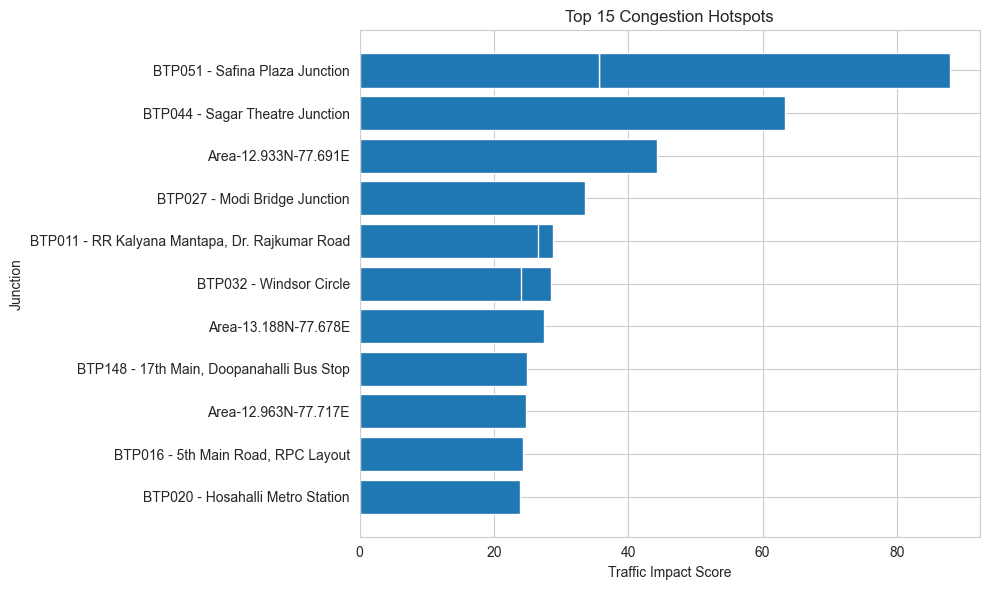

In [175]:
top15 = (
    priority
    .sort_values("traffic_impact_score", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
plt.barh(
    top15["junction_name"],
    top15["traffic_impact_score"]
)
plt.xlabel("Traffic Impact Score")
plt.ylabel("Junction")
plt.title("Top 15 Congestion Hotspots")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

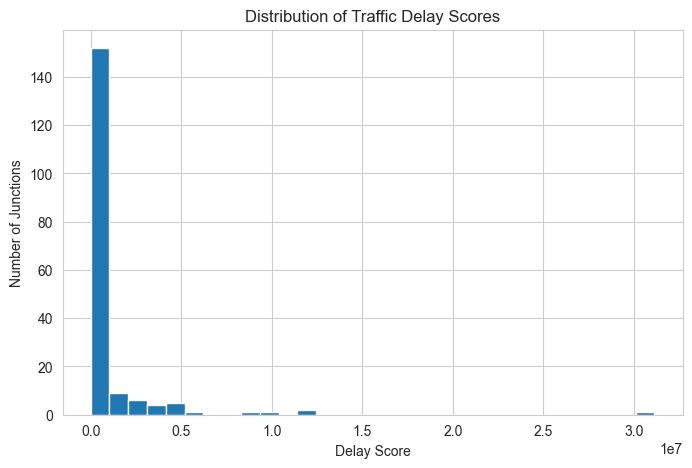

In [176]:
plt.figure(figsize=(8,5))
plt.hist(
    priority["delay_score"],
    bins=30
)
plt.xlabel("Delay Score")
plt.ylabel("Number of Junctions")
plt.title("Distribution of Traffic Delay Scores")
plt.show()

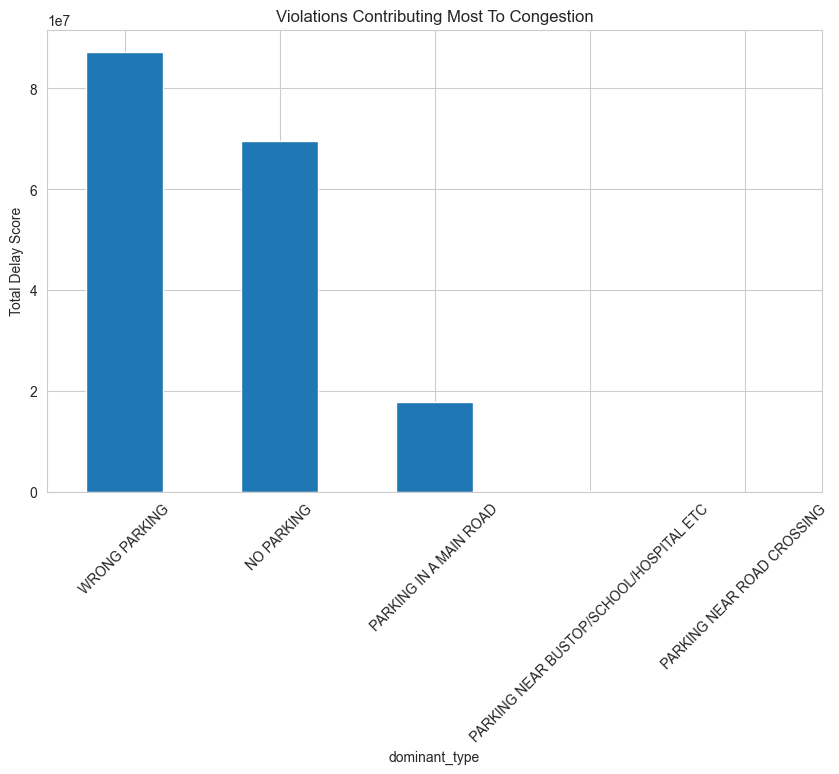

In [177]:
violation_delay = (
    priority
    .groupby("dominant_type")["delay_score"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

violation_delay.plot(kind="bar")

plt.ylabel("Total Delay Score")
plt.title("Violations Contributing Most To Congestion")
plt.xticks(rotation=45)

plt.show()

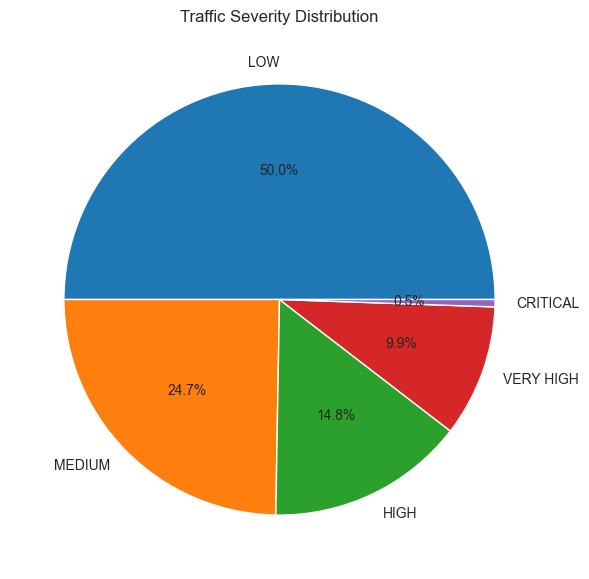

In [178]:
severity_counts = (
    priority["traffic_severity"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    severity_counts,
    labels=severity_counts.index,
    autopct="%1.1f%%"
)

plt.title("Traffic Severity Distribution")

plt.show()

In [179]:
import folium
from folium.plugins import HeatMap

m = folium.Map(
    location=[
        priority["lat"].mean(),
        priority["lon"].mean()
    ],
    zoom_start=12
)

HeatMap(
    priority[
        ["lat","lon","delay_score"]
    ].values.tolist(),
    radius=18
).add_to(m)

m

In [140]:
set(priority["junction_name"]) - set(overlap_stats["junction_name"])

{'Area-12.821N-77.693E',
 'Area-12.836N-77.676E',
 'Area-12.844N-77.647E',
 'Area-12.858N-77.664E',
 'Area-12.874N-77.597E',
 'Area-12.874N-77.648E',
 'Area-12.881N-77.644E',
 'Area-12.889N-77.639E',
 'Area-12.896N-77.635E',
 'Area-12.896N-77.720E',
 'Area-12.903N-77.673E',
 'Area-12.903N-77.707E',
 'Area-12.911N-77.644E',
 'Area-12.911N-77.678E',
 'Area-12.911N-77.695E',
 'Area-12.918N-77.648E',
 'Area-12.918N-77.665E',
 'Area-12.918N-77.674E',
 'Area-12.926N-77.653E',
 'Area-12.933N-77.691E',
 'Area-12.940N-77.746E',
 'Area-12.948N-77.716E',
 'Area-12.956N-77.670E',
 'Area-12.956N-77.704E',
 'Area-12.956N-77.712E',
 'Area-12.956N-77.729E',
 'Area-12.963N-77.717E',
 'Area-12.963N-77.733E',
 'Area-12.971N-77.713E',
 'Area-12.978N-77.692E',
 'Area-12.978N-77.717E',
 'Area-12.985N-77.738E',
 'Area-12.986N-77.502E',
 'Area-12.986N-77.511E',
 'Area-12.993N-77.650E',
 'Area-12.993N-77.658E',
 'Area-12.993N-77.667E',
 'Area-12.993N-77.700E',
 'Area-13.000N-77.721E',
 'Area-13.001N-77.679E',


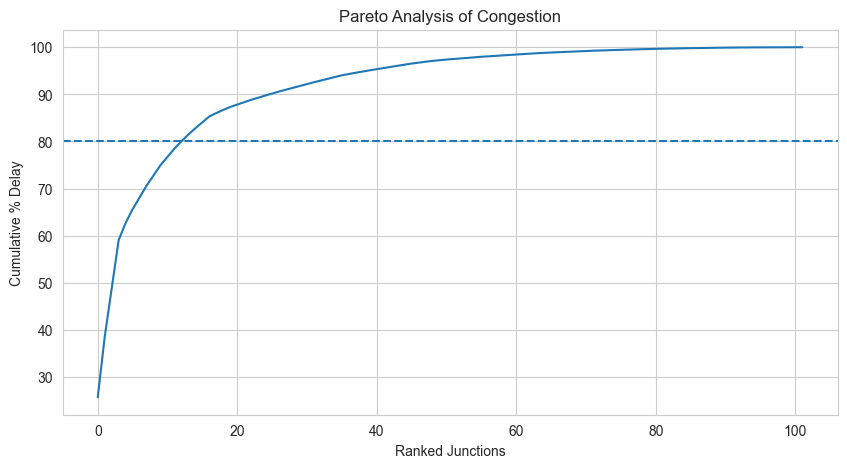

In [134]:
pareto = (
    priority
    .sort_values("delay_score", ascending=False)
)

pareto["cum_pct"] = (
    pareto["delay_score"].cumsum()
    / pareto["delay_score"].sum()
) * 100

plt.figure(figsize=(10,5))

plt.plot(
    range(len(pareto)),
    pareto["cum_pct"]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.ylabel("Cumulative % Delay")
plt.xlabel("Ranked Junctions")

plt.title("Pareto Analysis of Congestion")

plt.show()